In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ME\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [5]:
df = pd.read_csv(r"C:\Users\ME\Downloads\archive (15)\Reviews.csv")


In [6]:
print(df.shape)


(568454, 10)


In [7]:
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [8]:
print("=== شكل الداتا ===")
print(df.shape)

print("\n=== الأعمدة ===")
print(df.columns.tolist())

print("\n=== القيم المفقودة ===")
print(df.isnull().sum())

=== شكل الداتا ===
(568454, 10)

=== الأعمدة ===
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

=== القيم المفقودة ===
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


=== توزيع الـ Sentiment ===
sentiment
positive    443777
negative     82037
Name: count, dtype: int64

نسبة Positive: 84.4%


C:\Users\ME\AppData\Local\Temp\ipykernel_21960\1718422308.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette=['#e94560', '#00d4ff'])


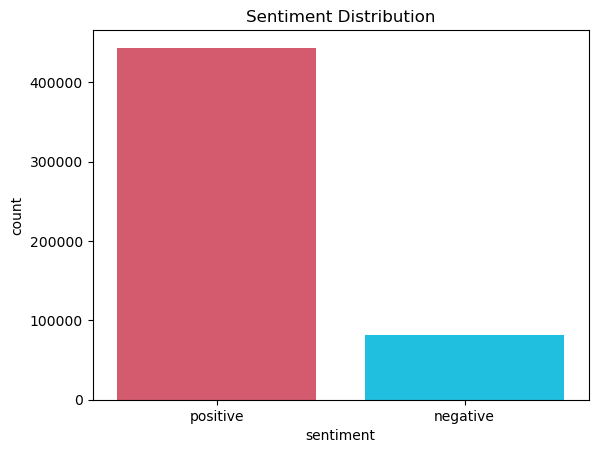

In [9]:
# تحويل الـ Score لـ Positive/Negative
# Score 4-5 = Positive, Score 1-2 = Negative, Score 3 = Neutral (هنشيله)
df = df[df['Score'] != 3]
df['sentiment'] = df['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')

print("=== توزيع الـ Sentiment ===")
print(df['sentiment'].value_counts())
print(f"\nنسبة Positive: {df['sentiment'].value_counts(normalize=True)['positive']*100:.1f}%")

sns.countplot(x='sentiment', data=df, palette=['#e94560', '#00d4ff'])
plt.title('Sentiment Distribution')
plt.show()

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['Text'].apply(clean_text)
print("✅ تم تنظيف النصوص")
print(df['clean_text'].head(3))

✅ تم تنظيف النصوص
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around centuries light pillowy citr...
Name: clean_text, dtype: object


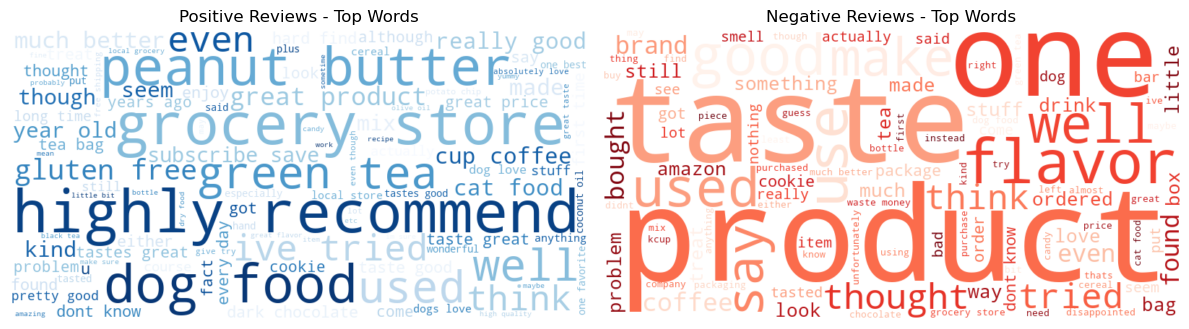

In [11]:
# Word Cloud للـ Positive
positive_text = ' '.join(df[df['sentiment'] == 'positive']['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='Blues', max_words=100).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Positive Reviews - Top Words')
plt.axis('off')

# Word Cloud للـ Negative
negative_text = ' '.join(df[df['sentiment'] == 'negative']['clean_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds', max_words=100).generate(negative_text)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Negative Reviews - Top Words')
plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Sample عشان الداتا كبيرة جداً
df_sample = df.sample(50000, random_state=42)

X = df_sample['clean_text']
y = df_sample['sentiment']

# تقسيم الداتا
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train:", X_train_tfidf.shape)
print("Test:", X_test_tfidf.shape)
print("✅ تم تجهيز الداتا")

Train: (40000, 10000)
Test: (10000, 10000)
✅ تم تجهيز الداتا


=== Naive Bayes Results ===
              precision    recall  f1-score   support

    negative       0.91      0.29      0.44      1571
    positive       0.88      1.00      0.94      8429

    accuracy                           0.88     10000
   macro avg       0.90      0.64      0.69     10000
weighted avg       0.89      0.88      0.86     10000



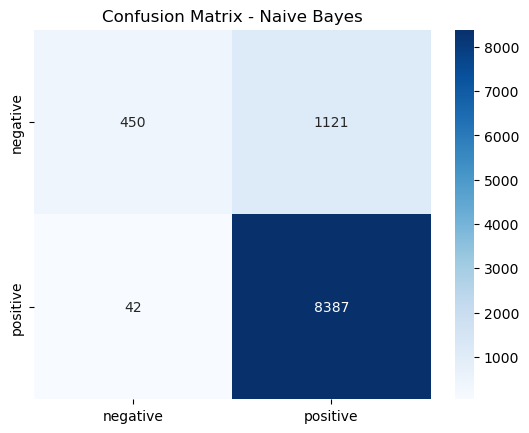

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes Results ===")
print(classification_report(y_test, y_pred_nb))

sns.heatmap(confusion_matrix(y_test, y_pred_nb),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

In [22]:
from collections import Counter

# بناء الـ Vocabulary
def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {word: idx+2 for idx, (word, _) in enumerate(counter.most_common(max_words))}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_seq(text, vocab, max_len=100):
    seq = [vocab.get(word, 1) for word in text.split()]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    return seq[:max_len]

MAX_WORDS = 10000
MAX_LEN = 100

vocab = build_vocab(X_train, MAX_WORDS)

X_train_seq = np.array([text_to_seq(t, vocab, MAX_LEN) for t in X_train])
X_test_seq  = np.array([text_to_seq(t, vocab, MAX_LEN) for t in X_test])

y_train_bin = (y_train == 'positive').astype(int).values
y_test_bin  = (y_test == 'positive').astype(int).values

print("✅ تم تجهيز الداتا بدون TensorFlow")
print("X_train shape:", X_train_seq.shape)

✅ تم تجهيز الداتا بدون TensorFlow
X_train shape: (40000, 100)


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(ReviewDataset(X_train_seq, y_train_bin), batch_size=64, shuffle=True)
test_loader  = DataLoader(ReviewDataset(X_test_seq, y_test_bin), batch_size=64)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(MAX_WORDS + 2, 64)
        self.lstm = nn.LSTM(64, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        x = self.dropout(h[-1])
        return torch.sigmoid(self.fc(x)).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = LSTMModel().to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Training
for epoch in range(3):
    lstm_model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = lstm_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/3 — Loss: {total_loss/len(train_loader):.4f}")

print("✅ Training Done!")

Epoch 1/3 — Loss: 0.4424
Epoch 2/3 — Loss: 0.4364
Epoch 3/3 — Loss: 0.4316
✅ Training Done!


=== LSTM Results ===
              precision    recall  f1-score   support

    negative       0.64      0.01      0.01      1571
    positive       0.84      1.00      0.91      8429

    accuracy                           0.84     10000
   macro avg       0.74      0.50      0.46     10000
weighted avg       0.81      0.84      0.77     10000



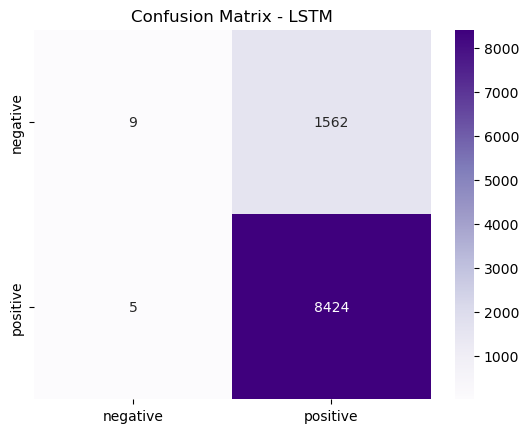

In [24]:
lstm_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = lstm_model(X_batch)
        preds = (output.cpu().numpy() > 0.5).astype(int)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy().astype(int))

print("=== LSTM Results ===")
print(classification_report(all_labels, all_preds, 
      target_names=['negative', 'positive']))

sns.heatmap(confusion_matrix(all_labels, all_preds),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix - LSTM')
plt.show()

=== Model Comparison ===
         Model  F1_Score
0  Naive Bayes     0.935
1         LSTM     0.915


C:\Users\ME\AppData\Local\Temp\ipykernel_21960\291704426.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_Score', data=results, palette=['#00d4ff', '#e94560'])


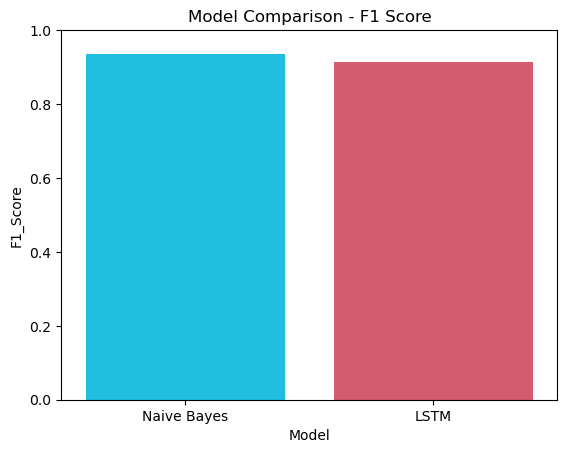


✅ Best Model: Naive Bayes


In [25]:
nb_f1 = f1_score(y_test, y_pred_nb, pos_label='positive')
lstm_f1 = f1_score(all_labels, all_preds)

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'LSTM'],
    'F1_Score': [round(nb_f1, 3), round(lstm_f1, 3)]
})

print("=== Model Comparison ===")
print(results)

sns.barplot(x='Model', y='F1_Score', data=results, palette=['#00d4ff', '#e94560'])
plt.title('Model Comparison - F1 Score')
plt.ylim(0, 1)
plt.show()

print(f"\n✅ Best Model: {'LSTM' if lstm_f1 > nb_f1 else 'Naive Bayes'}")

In [26]:
# 1. توزيع الـ Sentiment
sentiment_dist = df['sentiment'].value_counts().reset_index()
sentiment_dist.columns = ['sentiment', 'count']
sentiment_dist.to_csv('sentiment_distribution.csv', index=False)

# 2. Model Results
results.to_csv('sentiment_model_results.csv', index=False)

# 3. Sample Data
df.sample(500, random_state=42)[['Text', 'Score', 'sentiment', 'clean_text']].to_csv('sentiment_sample.csv', index=False)

# 4. Top Words
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(texts, n=20):
    cv = CountVectorizer(max_features=n)
    cv.fit_transform(texts)
    return list(cv.vocabulary_.keys())

top_positive = get_top_words(df[df['sentiment']=='positive']['clean_text'])
top_negative = get_top_words(df[df['sentiment']=='negative']['clean_text'])

top_words_df = pd.DataFrame({
    'positive_words': top_positive,
    'negative_words': top_negative
})
top_words_df.to_csv('top_words.csv', index=False)

print("✅ اتصدرت 4 ملفات:")
print("   - sentiment_distribution.csv")
print("   - sentiment_model_results.csv")
print("   - sentiment_sample.csv")
print("   - top_words.csv")

✅ اتصدرت 4 ملفات:
   - sentiment_distribution.csv
   - sentiment_model_results.csv
   - sentiment_sample.csv
   - top_words.csv
